라이브러리 임포트

In [1]:
import os
import chardet
import platform
import folium
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pyproj import Transformer
from branca.element import Template, MacroElement

원천 데이터에서 2024년 필터링

In [2]:
# 파일 경로 사전
file_paths = {
    "상권변화지표": "./Original_data/서울시 상권분석서비스(상권변화지표-상권).csv",
    "집객시설": "./Original_data/서울시 상권분석서비스(집객시설-상권).csv",
    "상주인구": "./Original_data/서울시 상권분석서비스(상주인구-상권).csv",
    "직장인구": "./Original_data/서울시 상권분석서비스(직장인구-상권).csv",
    "길단위인구": "./Original_data/서울시 상권분석서비스(길단위인구-상권).csv",
    "소득소비": "./Original_data/서울시 상권분석서비스(소득소비-상권).csv"
}

# 필터 기준: 2024년 1~4분기
target_year_codes = [20241, 20242, 20243, 20244]

# 결과 저장 딕셔너리
filtered_2024 = {}

# 저장 폴더 생성
output_dir = "./filtered"
os.makedirs(output_dir, exist_ok=True)

# 파일별 처리
for name, path in file_paths.items():
    try:
        df = pd.read_csv(path, encoding='cp949')

        # '기준_년분기_코드' 또는 유사한 컬럼명 자동 탐색
        year_col = [col for col in df.columns if '기준' in col and '년' in col]
        if year_col:
            df_filtered = df[df[year_col[0]].isin(target_year_codes)]
            filtered_2024[name] = df_filtered

            # 파일 저장
            save_path = os.path.join(output_dir, f"{name}_2024.csv")
            df_filtered.to_csv(save_path, index=False, encoding='utf-8-sig')
            print(f"✅ {name}_2024.csv 저장 완료")
        else:
            print(f"⚠️ '{name}' 파일에서 기준년도 컬럼을 찾을 수 없음")
    except Exception as e:
        print(f"❌ {name} 처리 중 오류 발생: {e}")


✅ 상권변화지표_2024.csv 저장 완료
✅ 집객시설_2024.csv 저장 완료
✅ 상주인구_2024.csv 저장 완료
✅ 직장인구_2024.csv 저장 완료
✅ 길단위인구_2024.csv 저장 완료
✅ 소득소비_2024.csv 저장 완료


PCA 분석_2024

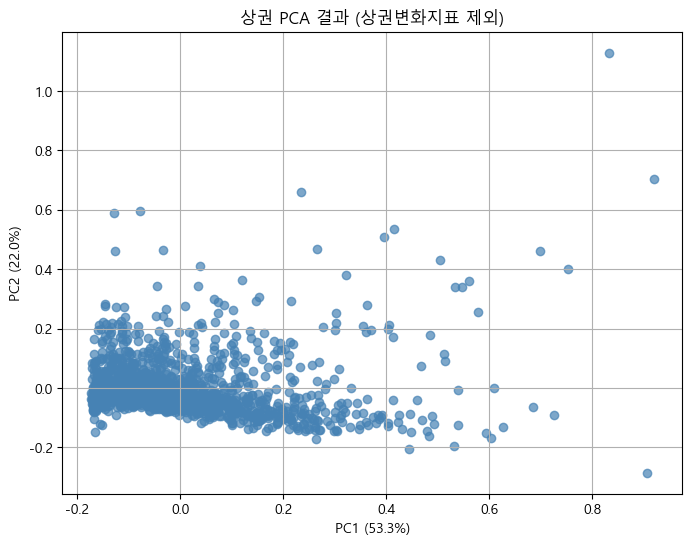

In [3]:
# 파일 경로 설정
area_path = "./Original_data/서울시 상권분석서비스(영역-상권).csv"
sales_path = "./Original_data/서울시 상권분석서비스(추정매출-상권)_2024년.csv"
store_path = "./Original_data/서울시 상권분석서비스(점포-상권)_2024년.csv"
income_path = "./filtered/소득소비_2024.csv"
worker_path = "./filtered/직장인구_2024.csv"
facility_path = "./filtered/집객시설_2024.csv"
floating_path = "./filtered/길단위인구_2024.csv"
resident_path = "./filtered/상주인구_2024.csv"
change_path = "./filtered/상권변화지표_2024.csv"

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # macOS
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스 계열 대안

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 인코딩 자동 감지 함수
def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        raw_data = f.read(100000)
    result = chardet.detect(raw_data)
    return result['encoding']

# 인코딩 감지
file_paths = {'area': area_path, 'sales': sales_path, 'store': store_path,
              'income': income_path, 'worker': worker_path, 'facility': facility_path,
              'floating': floating_path, 'resident': resident_path, 'change': change_path}
encodings = {name: detect_encoding(path) for name, path in file_paths.items()}

# 파일 불러오기
area = pd.read_csv(area_path, encoding=encodings['area'])
sales = pd.read_csv(sales_path, encoding=encodings['sales'])
store = pd.read_csv(store_path, encoding=encodings['store'])
income = pd.read_csv(income_path, encoding=encodings['income'])
worker = pd.read_csv(worker_path, encoding=encodings['worker'])
facility = pd.read_csv(facility_path, encoding=encodings['facility'])
floating = pd.read_csv(floating_path, encoding=encodings['floating'])
resident = pd.read_csv(resident_path, encoding=encodings['resident'])
change = pd.read_csv(change_path, encoding=encodings['change'])

# 상권별 집계
merge_key = '상권_코드'
sales_sum = sales.groupby(merge_key)['당월_매출_금액'].sum().reset_index()
store_sum = store.groupby(merge_key)['점포_수'].sum().reset_index()
income_sum = income.groupby(merge_key)['월_평균_소득_금액'].mean().reset_index()
worker_sum = worker.groupby(merge_key)['총_직장_인구_수'].sum().reset_index()
facility_sum = facility.groupby(merge_key)['집객시설_수'].sum().reset_index()
floating_sum = floating.groupby(merge_key)['총_유동인구_수'].sum().reset_index()
resident_sum = resident.groupby(merge_key)['총_상주인구_수'].sum().reset_index()

# merge
df_full = sales_sum.merge(store_sum, on=merge_key)\
                   .merge(income_sum, on=merge_key)\
                   .merge(worker_sum, on=merge_key)\
                   .merge(facility_sum, on=merge_key)\
                   .merge(floating_sum, on=merge_key)\
                   .merge(resident_sum, on=merge_key)

df_full.columns = ['상권_코드', '매출', '점포수', '소득', '직장인구', '집객시설', '유동인구', '상주인구']

# 정규화 및 PCA 준비
pca_cols = ['매출', '점포수', '소득', '직장인구', '집객시설', '유동인구', '상주인구']
for col in pca_cols:
    df_full[f'{col}_정규화'] = (df_full[col] - df_full[col].min()) / (df_full[col].max() - df_full[col].min())

pca_data = df_full[[f'{col}_정규화' for col in pca_cols]].copy()

# PCA 수행
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_data)
explained_variance = pca.explained_variance_ratio_

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='steelblue', alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title('상권 PCA 결과 (상권변화지표 제외)')
plt.grid(True)
plt.show()

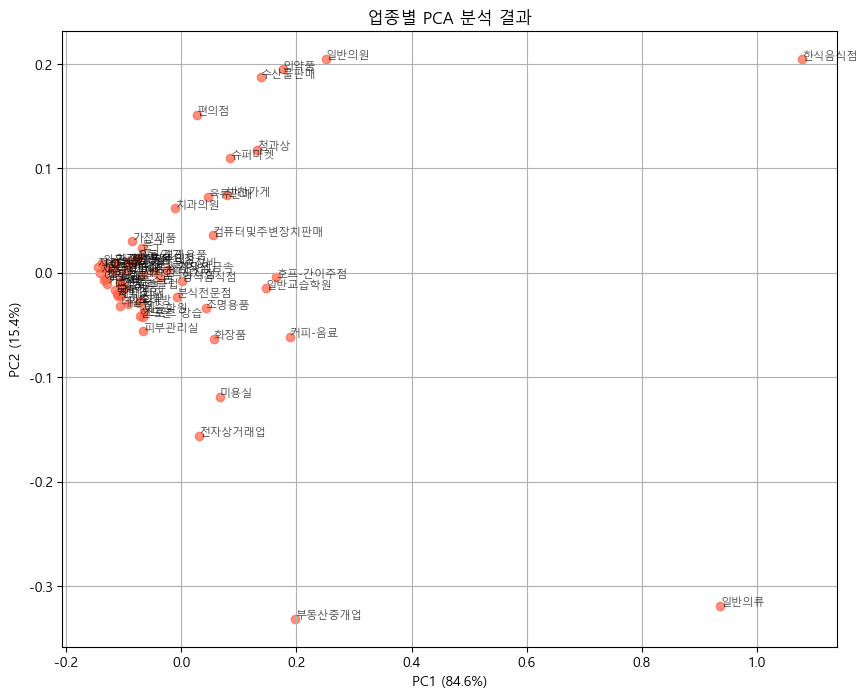

PCA 설명 분산 비율: [0.845712 0.154288]


In [4]:
# 업종별 총 매출과 점포수 집계
sales_sum_industry = sales.groupby('서비스_업종_코드_명')['당월_매출_금액'].sum().reset_index()
store_sum_industry = store.groupby('서비스_업종_코드_명')['점포_수'].sum().reset_index()

# 병합
industry_df = pd.merge(sales_sum_industry, store_sum_industry, on='서비스_업종_코드_명')

# 정규화
industry_df['매출_정규화'] = (industry_df['당월_매출_금액'] - industry_df['당월_매출_금액'].min()) / (industry_df['당월_매출_금액'].max() - industry_df['당월_매출_금액'].min())
industry_df['점포수_정규화'] = (industry_df['점포_수'] - industry_df['점포_수'].min()) / (industry_df['점포_수'].max() - industry_df['점포_수'].min())

# PCA 데이터 구성
pca_data_industry = industry_df[['매출_정규화', '점포수_정규화']]

# PCA 수행 (2차원으로)
pca_industry = PCA(n_components=2)
pca_result_industry = pca_industry.fit_transform(pca_data_industry)
explained_variance_industry = pca_industry.explained_variance_ratio_

# 시각화
plt.figure(figsize=(10, 8))
plt.scatter(pca_result_industry[:, 0], pca_result_industry[:, 1], c='tomato', alpha=0.7)

# 업종명 표시 (한글 깨짐 주의 — 폰트 지정 가능)
for i, txt in enumerate(industry_df['서비스_업종_코드_명']):
    plt.annotate(txt, (pca_result_industry[i, 0], pca_result_industry[i, 1]), fontsize=8, alpha=0.7)

plt.xlabel(f'PC1 ({explained_variance_industry[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance_industry[1]*100:.1f}%)')
plt.title('업종별 PCA 분석 결과')
plt.grid(True)
plt.show()

# 결과 출력
print("PCA 설명 분산 비율:", explained_variance_industry)

군집화 분석_2024

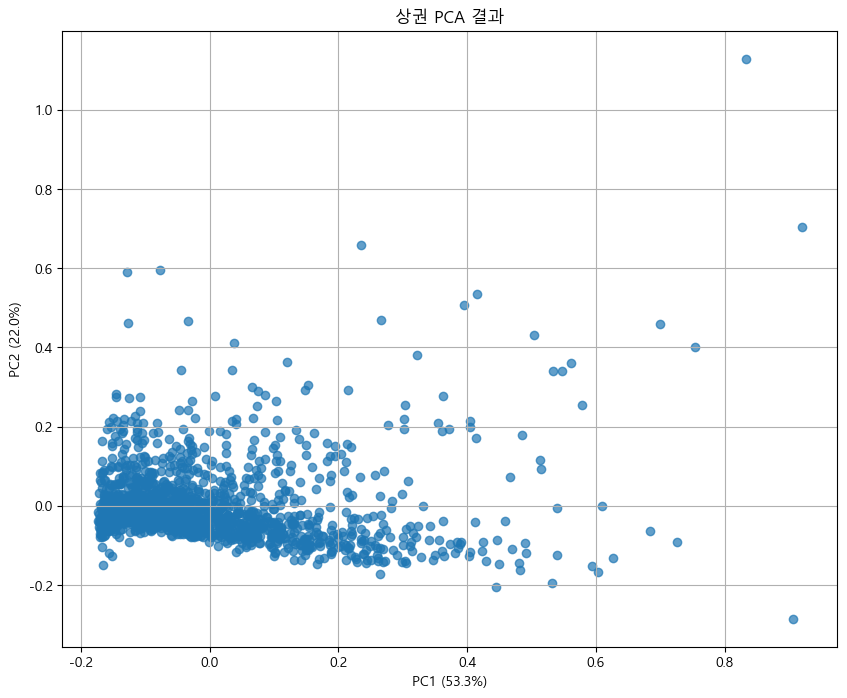

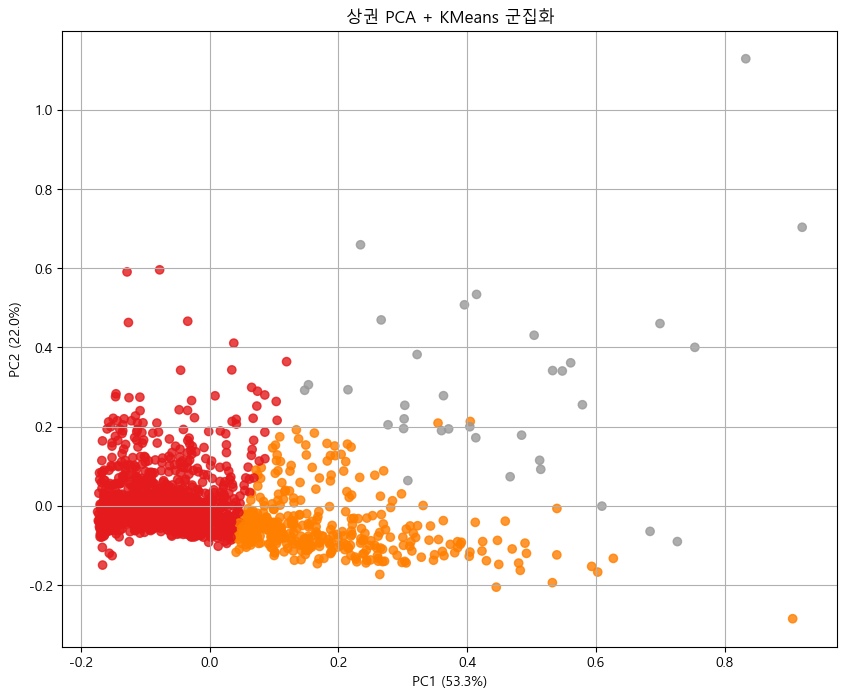

In [5]:
# 중복 컬럼 제서 후 csv 읽기
def read_clean_csv(file_path, encoding):
    df = pd.read_csv(file_path, encoding=encoding)
    df = df.loc[:, ~df.columns.duplicated()]
    return df

sales = read_clean_csv(sales_path, encodings['sales'])
store = read_clean_csv(store_path, encodings['store'])
income = read_clean_csv(income_path, encodings['income'])
worker = read_clean_csv(worker_path, encodings['worker'])
facility = read_clean_csv(facility_path, encodings['facility'])
floating = read_clean_csv(floating_path, encodings['floating'])
resident = read_clean_csv(resident_path, encodings['resident'])
change = read_clean_csv(change_path, encodings['change'])

#지표별 상권 단위 집계
merge_key = '상권_코드'

sales_sum = sales.groupby(merge_key)['당월_매출_금액'].sum().reset_index()
store_sum = store.groupby(merge_key)['점포_수'].sum().reset_index()
income_sum = income.groupby(merge_key)['월_평균_소득_금액'].mean().reset_index()
worker_sum = worker.groupby(merge_key)['총_직장_인구_수'].sum().reset_index()
facility_sum = facility.groupby(merge_key)['집객시설_수'].sum().reset_index()
floating_sum = floating.groupby(merge_key)['총_유동인구_수'].sum().reset_index()
resident_sum = resident.groupby(merge_key)['총_상주인구_수'].sum().reset_index()

#데이터병합
df_full = sales_sum.merge(store_sum, on=merge_key)\
                   .merge(income_sum, on=merge_key)\
                   .merge(worker_sum, on=merge_key)\
                   .merge(facility_sum, on=merge_key)\
                   .merge(floating_sum, on=merge_key)\
                   .merge(resident_sum, on=merge_key)

df_full.columns = ['상권_코드', '매출', '점포수', '소득', '직장인구', '집객시설', '유동인구', '상주인구']

# 정규화
scaler = MinMaxScaler()
features = ['매출', '점포수', '소득', '직장인구', '집객시설', '유동인구', '상주인구']
df_full_scaled = scaler.fit_transform(df_full[features])

# PCA 분석
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_full_scaled)

# 시각화
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('상권 PCA 결과')
plt.grid(True)
plt.show()

# 군집화
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_full['Cluster'] = kmeans.fit_predict(df_full_scaled)

# 군집화 시각화
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_full['Cluster'], cmap='Set1', alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('상권 PCA + KMeans 군집화')
plt.grid(True)
plt.show()


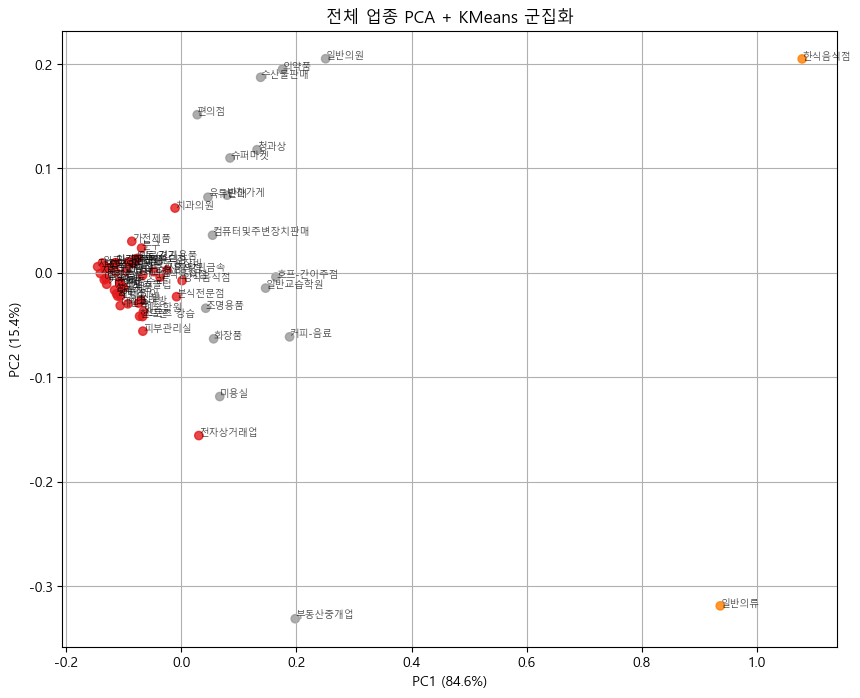

,서비스_업종_코드_명,Cluster
0,PC방,0
1,가구,0
2,가방,0
3,가전제품,0
4,가전제품수리,0
...,...,...
57,컴퓨터및주변장치판매,2
58,청과상,2
59,커피-음료,2
60,호프-간이주점,2


In [6]:
# 중복 컬럼 제거 후 CSV 불러오기
def read_clean_csv(file_path, encoding):
    df = pd.read_csv(file_path, encoding=encoding)
    df = df.loc[:, ~df.columns.duplicated()]
    return df

sales = read_clean_csv(sales_path, encodings['sales'])
store = read_clean_csv(store_path, encodings['store'])

# 업종별 매출 및 점포 수 집계
sales_sum = sales.groupby('서비스_업종_코드_명')['당월_매출_금액'].sum().reset_index()
store_sum = store.groupby('서비스_업종_코드_명')['점포_수'].sum().reset_index()

# 매출 + 점포 수 데이터 병합
industry_df = pd.merge(sales_sum, store_sum, on='서비스_업종_코드_명')

# 정규화
scaler = MinMaxScaler()
industry_df[['매출_정규화', '점포수_정규화']] = scaler.fit_transform(industry_df[['당월_매출_금액', '점포_수']])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(industry_df[['매출_정규화', '점포수_정규화']])

# KMeans 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_result)
industry_df['Cluster'] = clusters

# 시각
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='Set1', alpha=0.8)
for i, txt in enumerate(industry_df['서비스_업종_코드_명']):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=7, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('전체 업종 PCA + KMeans 군집화')
plt.grid(True)
plt.show()

# 군집별 업종 정리 테이블 생성
industry_result = industry_df[['서비스_업종_코드_명', 'Cluster']].sort_values(by='Cluster')
industry_result.reset_index(drop=True, inplace=True)
industry_result

In [7]:
# 1. 데이터 준비
sales_df = pd.read_csv("./Original_data/서울시 상권분석서비스(추정매출-상권)_2024년.csv", encoding="utf-8-sig")
area_df = pd.read_csv("./Original_data/서울시 상권분석서비스(영역-상권).csv", encoding="cp949")

# 2. 군집된 업종을 기준으로 상권 × 군집 조합 매출 집계
sales_clustered = sales_df.merge(industry_result, on="서비스_업종_코드_명", how="inner")

# 3. 상위 15개 상권 + 노원구
top_15_areas = (
    sales_df.groupby("상권_코드_명")["당월_매출_금액"]
    .sum().sort_values(ascending=False).head(15).index.tolist()
)
nowon_areas = ["노원역", "노원역 9번", "노원초등학교"]
selected_areas = top_15_areas + nowon_areas

# 4. 피벗: 상권 × 업종군집 매출합
pivot = sales_clustered[
    sales_clustered["상권_코드_명"].isin(selected_areas)
].pivot_table(
    index="상권_코드_명",
    columns="Cluster",
    values="당월_매출_금액",
    aggfunc="sum",
    fill_value=0
)

# 5. 상권 단위 KMeans 군집화
scaler = StandardScaler()
X = scaler.fit_transform(pivot)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
area_clusters = kmeans.fit_predict(X)

# 6. 결과 저장
result_df = pivot.copy()
result_df["군집"] = area_clusters
result_df.reset_index(inplace=True)
result_df.rename(columns={"상권_코드_명": "상권"}, inplace=True)

# 7. 좌표 변환 (TM → 위경도)
coords_df = area_df[["상권_코드_명", "엑스좌표_값", "와이좌표_값"]].drop_duplicates()
coords_df.columns = ["상권", "경도_TM", "위도_TM"]
transformer = Transformer.from_crs("epsg:2097", "epsg:4326", always_xy=True)
coords_df[["경도", "위도"]] = coords_df.apply(
    lambda row: transformer.transform(row["경도_TM"], row["위도_TM"]),
    axis=1, result_type="expand"
)

# 8. 병합
map_df = result_df.merge(coords_df[["상권", "위도", "경도"]], on="상권", how="left")
map_df_clean = map_df.dropna(subset=["위도", "경도"])

# 9. 지도 생성
color_map = {0: "red", 1: "green", 2: "blue"}
m = folium.Map(location=[map_df_clean["위도"].mean(), map_df_clean["경도"].mean()], zoom_start=12)

for _, row in map_df_clean.iterrows():
    if row["상권"] in nowon_areas:
        folium.Marker(
            location=[row["위도"], row["경도"]],
            popup=f"{row['상권']}<br>(Cluster ?)",
            icon=folium.Icon(color="orange", icon="info-sign")
        ).add_to(m)
    else:
        folium.Marker(
            location=[row["위도"], row["경도"]],
            popup=f"{row['상권']}<br>(Cluster {row['군집']})",
            icon=folium.Icon(color=color_map[row["군집"]], icon="info-sign")
        ).add_to(m)

# 10. 범례
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 220px;
    height: 140px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 10px;
    line-height: 1.6;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
">
<b>군집 색상 범례</b><br>
🔴 Cluster 0 (red)<br>
🟢 Cluster 1 (green)<br>
🔵 Cluster 2 (blue)<br>
🟠 노원구 (orange)
</div>
"""
legend = MacroElement()
legend._template = Template(f"""
    {{% macro html(this, kwargs) %}}
    {legend_html}
    {{% endmacro %}}
""")
m.get_root().add_child(legend)

# 11. 저장 및 출력
m.save("상권_군집_지도_최종.html")
m